# 03 — The Models

**What do the models actually predict, where do they fail, and what can you trust?**

Three models were trained: a Ridge regression baseline, XGBoost, and LightGBM. All were tuned with Optuna on the validation set (2019Q1–2020Q4) and evaluated on a held-out test set (2021Q1–2021Q4) that was never touched during training or tuning.

This notebook answers:
- How do the models compare on standard metrics?
- What does "actual vs predicted" look like over time?
- Why are the test R² values so negative, and should we be alarmed?
- Which features drive the predictions?
- What are the models actually useful for in practice?

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.data.pipeline import load_panel
from src.data.config import CITIES, SplitConfig
from src.features.pipeline import FeaturePipeline
from src.models.registry import ModelRegistry
from src.models.evaluator import evaluate

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CITY_COLORS = dict(zip(CITIES, sns.color_palette("tab10", len(CITIES))))
MODEL_COLORS = {"ridge": "#9467bd", "xgboost": "#1f77b4", "lgbm": "#2ca02c"}
SPLIT = SplitConfig()

In [2]:
# Load data and build features
panel = load_panel()
pipeline = FeaturePipeline()
feat_df = pipeline.build(panel)

X_train, y_train = pipeline.get_X_y(feat_df, "train", SPLIT)
X_val,   y_val   = pipeline.get_X_y(feat_df, "val",   SPLIT)
X_test,  y_test  = pipeline.get_X_y(feat_df, "test",  SPLIT)

# Load all trained models from registry
registry = ModelRegistry()
model_list = registry.list_models()

models = {}
metadata = {}
for entry in model_list:
    name = entry["name"]
    m, meta = registry.load(name, entry["version"])
    models[name] = m
    metadata[name] = meta

print(f"Loaded models: {list(models.keys())}")
print(f"Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}")

Loaded models: ['xgboost', 'lgbm', 'ridge']
Train: 216  Val: 64  Test: 24


## 1. Headline Metrics

All metrics computed on held-out splits. **Val** was used for hyperparameter tuning; **Test** was never seen during development.

- **MAE**: mean absolute error in percentage points of QoQ change
- **RMSE**: root-mean-squared error (penalises large errors more)
- **R²**: variance explained. Negative means worse than predicting the mean — alarming but explainable (see Section 4)
- **Dir. Acc.**: fraction of quarters where the model correctly predicts the *direction* (up or down)

In [3]:
rows = []
for name, model in models.items():
    for split_name, X_split, y_split in [("train", X_train, y_train),
                                          ("val",   X_val,   y_val),
                                          ("test",  X_test,  y_test)]:
        if len(X_split) == 0:
            continue
        preds = model.predict(X_split)
        m = evaluate(y_split, preds, split_name)
        rows.append({
            "model": name, "split": split_name,
            "MAE": round(m.mae, 3), "RMSE": round(m.rmse, 3),
            "R²": round(m.r2, 3), "Dir. Acc.": f"{m.directional_accuracy:.1%}",
            "N": m.n_samples,
        })

results_df = pd.DataFrame(rows)
results_df.set_index(["model", "split"])

MAE   RMSE     R² Dir. Acc.    N
model   split                                    
xgboost train  1.188  1.610  0.151     68.1%  216
        val    1.818  2.298 -0.137     70.3%   64
        test   4.460  4.920 -4.642    100.0%   24
lgbm    train  1.232  1.660  0.097     68.1%  216
        val    1.799  2.249 -0.089     70.3%   64
        test   4.515  4.971 -4.759    100.0%   24
ridge   train  0.853  1.201  0.528     86.1%  216
        val    1.733  2.411 -0.251     62.5%   64
        test   4.845  5.332 -5.628     91.7%   24

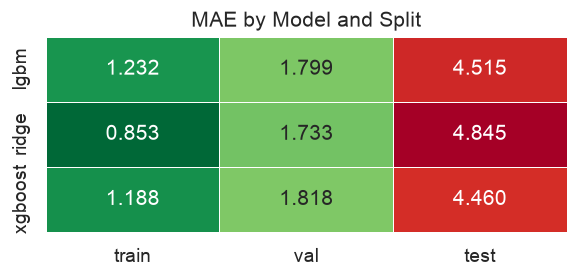

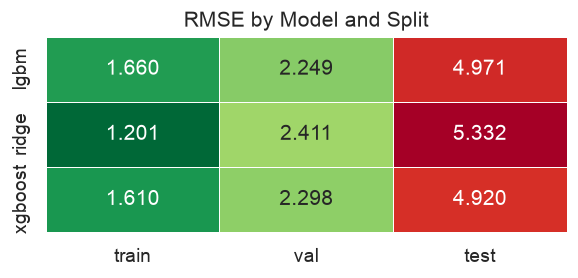

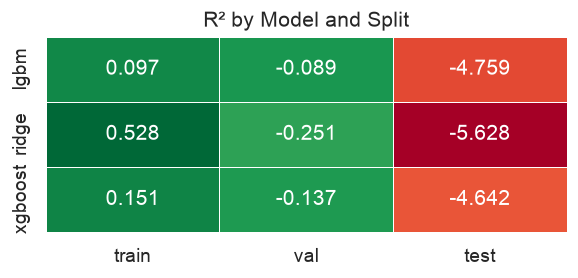

In [4]:
# Visual metrics heatmap
for metric in ["MAE", "RMSE", "R²"]:
    pivot = results_df.pivot(index="model", columns="split", values=metric)
    pivot = pivot[["train", "val", "test"]]  # order columns

    fig, ax = plt.subplots(figsize=(5, 2.5))
    # Reverse cmap for R² (higher is better)
    cmap = "RdYlGn" if metric == "R²" else "RdYlGn_r"
    sns.heatmap(pivot.astype(float), annot=True, fmt=".3f", cmap=cmap,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(f"{metric} by Model and Split")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 2. Actual vs Predicted — Validation Split

The validation period (2019Q1–2020Q4) includes the beginning of COVID but mostly "normal" market conditions. Here we can see what the models are doing in their best-case operating window.

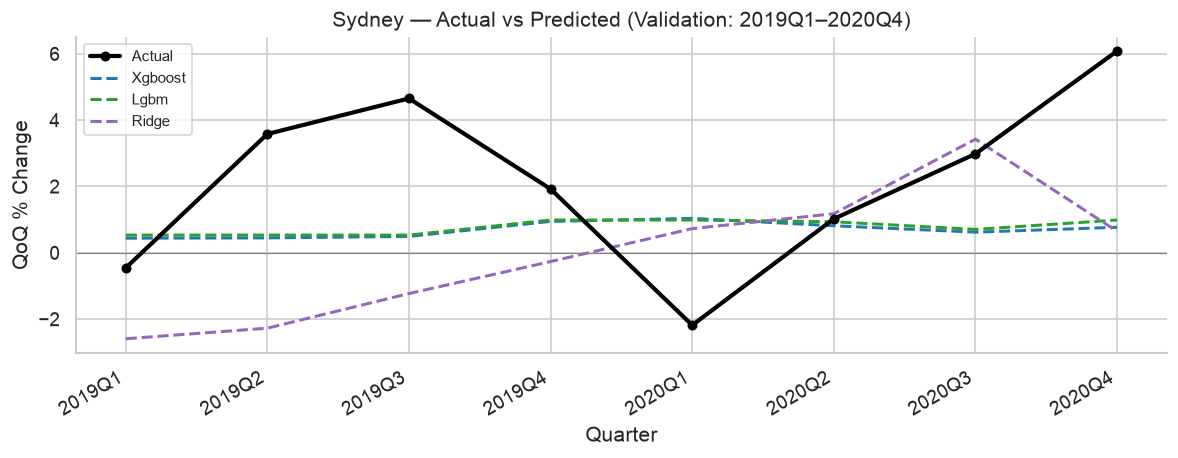

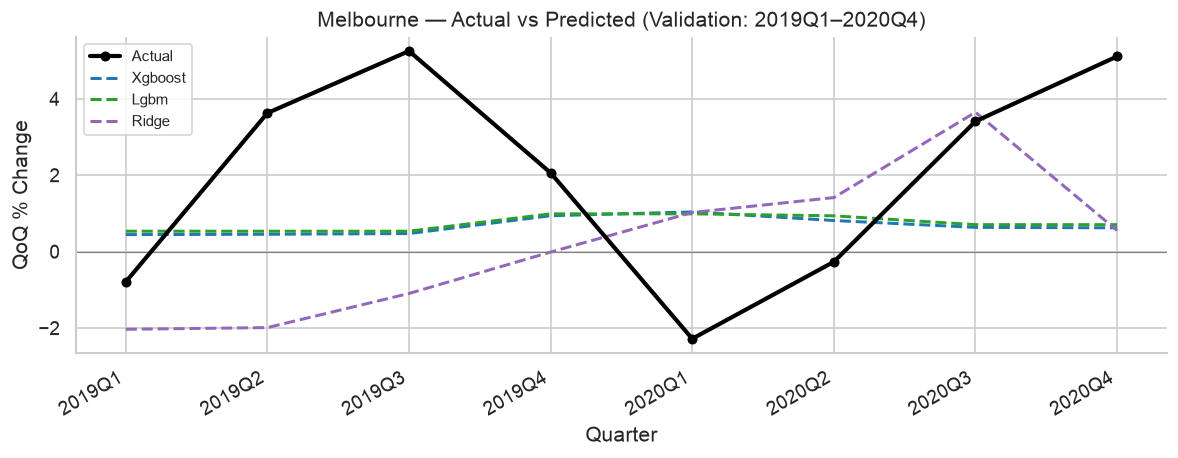

In [5]:
# Build prediction frame for val split
val_rows = feat_df[
    (feat_df["period"] > pd.Period(SPLIT.train_end, freq="Q-DEC")) &
    (feat_df["period"] <= pd.Period(SPLIT.val_end, freq="Q-DEC"))
].copy()

for name, model in models.items():
    val_rows[f"pred_{name}"] = model.predict(X_val)

for city in ["Sydney", "Melbourne"]:
    df_city = val_rows[val_rows["city"] == city].sort_values("period")
    x = [str(p) for p in df_city["period"]]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, df_city["target"], "k-o", linewidth=2.5, markersize=5, label="Actual", zorder=5)
    for name in models:
        ax.plot(x, df_city[f"pred_{name}"], linestyle="--",
                color=MODEL_COLORS[name], linewidth=1.8, label=name.capitalize())
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("QoQ % Change")
    ax.set_title(f"{city} — Actual vs Predicted (Validation: 2019Q1–2020Q4)")
    ax.legend(fontsize=9)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 3. The 2021 Problem — Why Test R² Is Negative

A negative R² means the model does *worse* than just predicting the mean. That sounds bad — but context matters enormously here.

The test period (2021Q1–2021Q4) saw Australian cities post quarterly price gains of **+4% to +8%** — the largest moves since the post-GFC recovery, driven by the RBA cutting rates to a historic low of 0.1%. 

The model was trained on a period where the cash rate ranged from 1.5% to 4.75%. It has *never seen* a 0.1% rate in its training data. This is a genuine out-of-distribution event — not a modelling failure, but a data coverage gap.

The chart below makes this vivid.

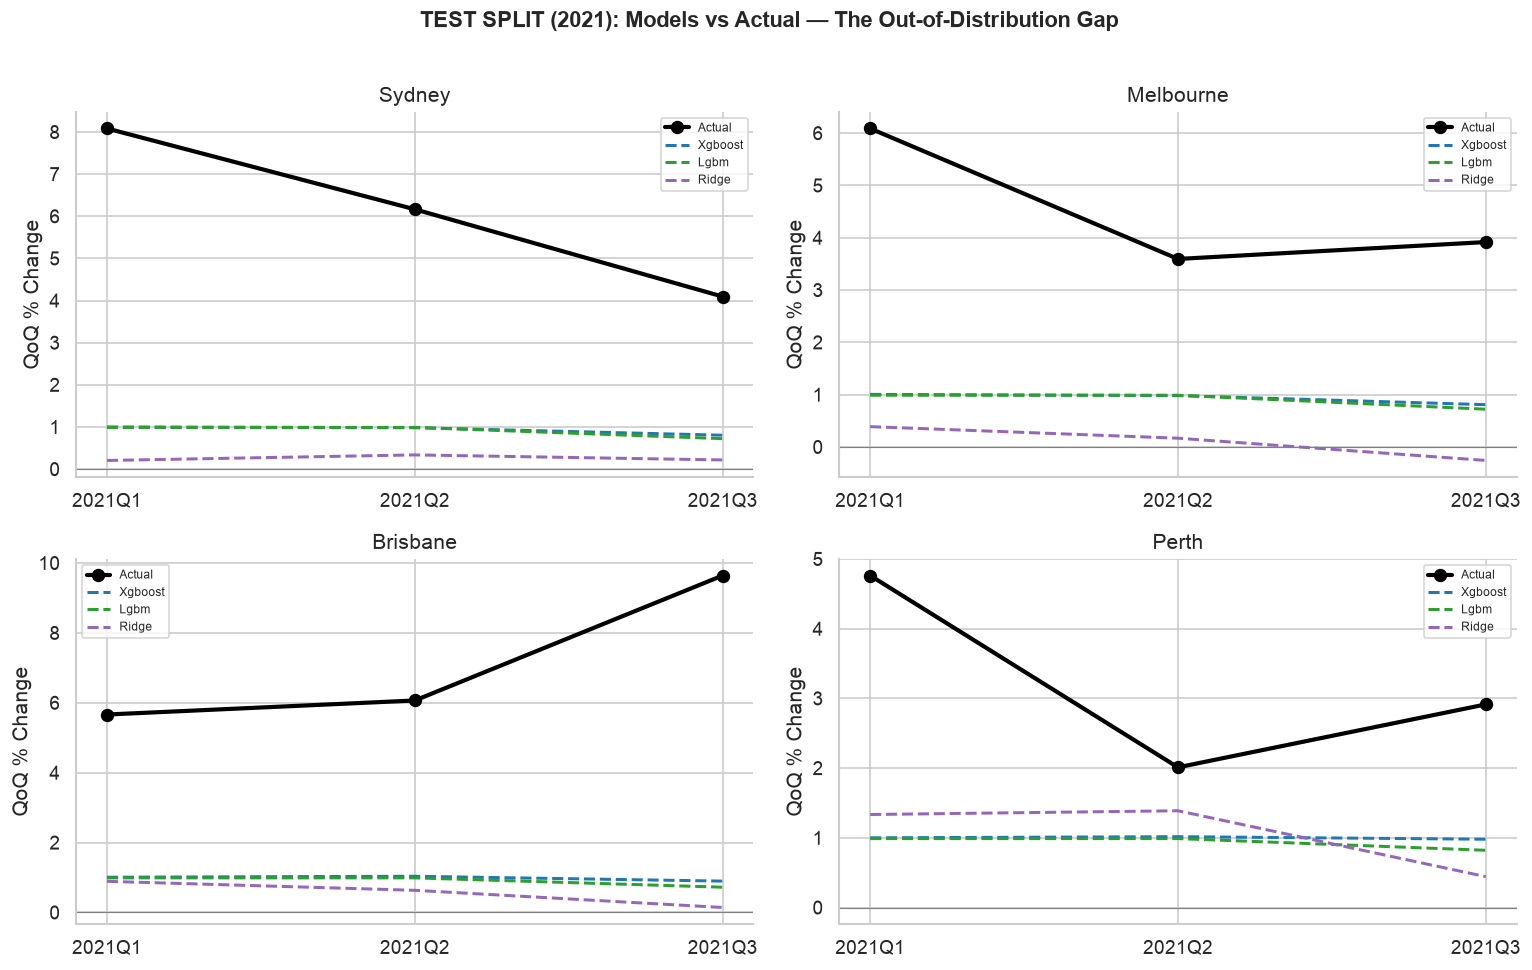

Cash rate during training: 1.50% – 4.75%
Cash rate during test:     0.10% – 0.10%

Test actual QoQ changes (all cities):
            min   max  mean
city                       
Adelaide   5.33  6.76  5.98
Brisbane   5.66  9.64  7.12
Canberra   5.98  8.23  6.86
Darwin     1.51  4.59  2.58
Hobart     6.26  8.18  6.97
Melbourne  3.59  6.09  4.53
Perth      2.01  4.76  3.23
Sydney     4.09  8.08  6.11


In [6]:
test_rows = feat_df[feat_df["period"] > pd.Period(SPLIT.val_end, freq="Q-DEC")].copy()
for name, model in models.items():
    test_rows[f"pred_{name}"] = model.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
cities_to_show = ["Sydney", "Melbourne", "Brisbane", "Perth"]

for ax, city in zip(axes.flat, cities_to_show):
    df_city = test_rows[test_rows["city"] == city].sort_values("period")
    x = [str(p) for p in df_city["period"]]
    ax.plot(x, df_city["target"], "k-o", linewidth=2.5, markersize=7, label="Actual", zorder=5)
    for name in models:
        ax.plot(x, df_city[f"pred_{name}"], linestyle="--",
                color=MODEL_COLORS[name], linewidth=1.8, label=name.capitalize())
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_title(city)
    ax.set_xlabel("")
    ax.set_ylabel("QoQ % Change")
    ax.legend(fontsize=7)

plt.suptitle("TEST SPLIT (2021): Models vs Actual — The Out-of-Distribution Gap",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Show the cash rate in 2021 vs training range
macro = panel[panel["city"] == "Sydney"].sort_values("period")
train_rates = macro[macro["period"] <= pd.Period(SPLIT.train_end, freq="Q-DEC")]["cash_rate"]
test_rates  = macro[macro["period"] > pd.Period(SPLIT.val_end,   freq="Q-DEC")]["cash_rate"]
print(f"Cash rate during training: {train_rates.min():.2f}% – {train_rates.max():.2f}%")
print(f"Cash rate during test:     {test_rates.min():.2f}% – {test_rates.max():.2f}%")
print(f"\nTest actual QoQ changes (all cities):")
print(test_rows.groupby("city")["target"].agg(["min", "max", "mean"]).round(2))

## 4. Prediction Intervals

XGBoost and LightGBM were trained with quantile regression (0.05 and 0.95 quantile models alongside the point forecast). This gives 90% prediction intervals. Wider bands = more uncertainty — and as you'll see, the models know they're uncertain in 2021.

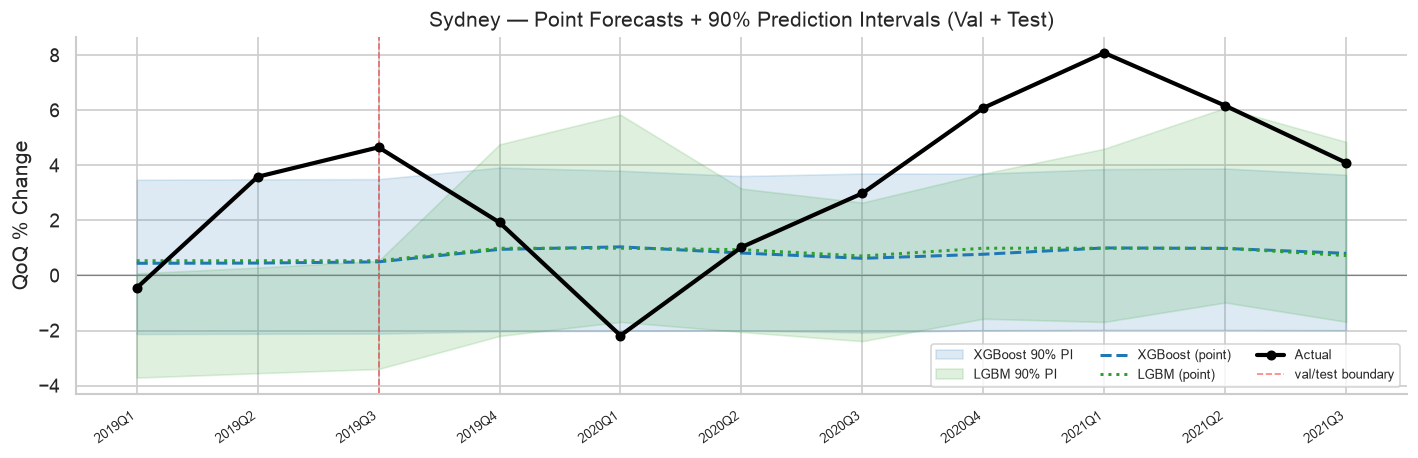

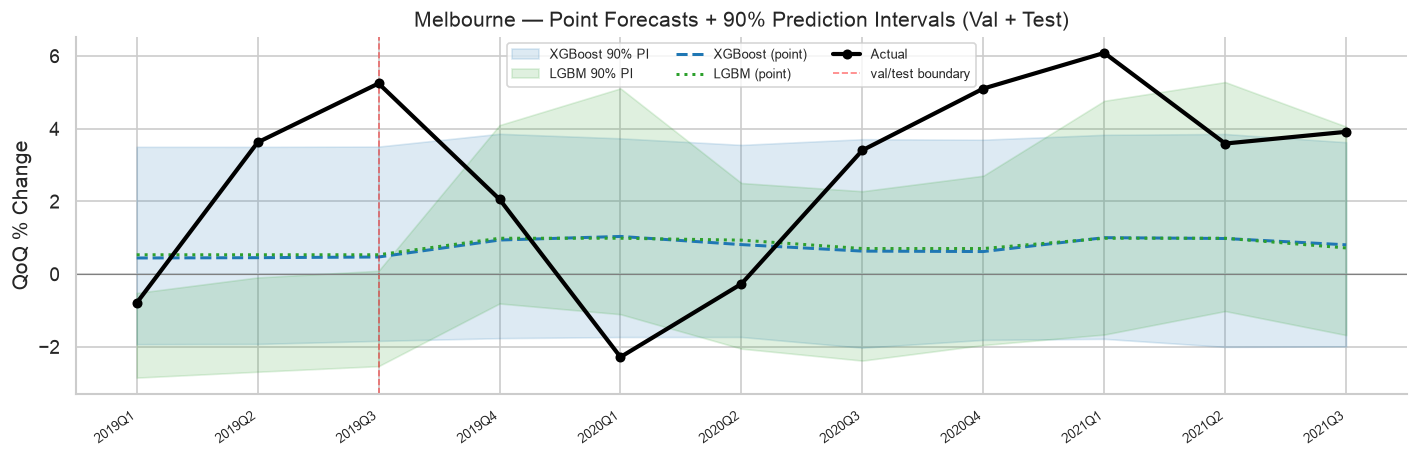

In [7]:
xgb_model = models["xgboost"]
lgbm_model = models["lgbm"]

# Combine val + test for a continuous picture
combined = feat_df[feat_df["period"] > pd.Period(SPLIT.train_end, freq="Q-DEC")].copy()
X_combined = combined[pipeline.feature_cols]

xgb_preds, xgb_lower, xgb_upper = xgb_model.predict_with_interval(X_combined, confidence=0.90)
lgbm_preds, lgbm_lower, lgbm_upper = lgbm_model.predict_with_interval(X_combined, confidence=0.90)

combined["xgb_pred"] = xgb_preds
combined["xgb_lower"] = xgb_lower
combined["xgb_upper"] = xgb_upper
combined["lgbm_pred"] = lgbm_preds
combined["lgbm_lower"] = lgbm_lower
combined["lgbm_upper"] = lgbm_upper

for city in ["Sydney", "Melbourne"]:
    df_city = combined[combined["city"] == city].sort_values("period")
    x = np.arange(len(df_city))
    x_labels = [str(p) for p in df_city["period"]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(x, df_city["xgb_lower"], df_city["xgb_upper"],
                    alpha=0.15, color=MODEL_COLORS["xgboost"], label="XGBoost 90% PI")
    ax.fill_between(x, df_city["lgbm_lower"], df_city["lgbm_upper"],
                    alpha=0.15, color=MODEL_COLORS["lgbm"], label="LGBM 90% PI")
    ax.plot(x, df_city["xgb_pred"], color=MODEL_COLORS["xgboost"],
            linewidth=1.8, linestyle="--", label="XGBoost (point)")
    ax.plot(x, df_city["lgbm_pred"], color=MODEL_COLORS["lgbm"],
            linewidth=1.8, linestyle=":", label="LGBM (point)")
    ax.plot(x, df_city["target"], "k-o", linewidth=2.5, markersize=5, label="Actual", zorder=5)
    ax.axvline(x[df_city["period"] > pd.Period(SPLIT.val_end, freq="Q-DEC")].argmax() if
               (df_city["period"] > pd.Period(SPLIT.val_end, freq="Q-DEC")).any() else -1,
               color="red", linestyle="--", alpha=0.5, linewidth=1, label="val/test boundary")
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("QoQ % Change")
    ax.set_title(f"{city} — Point Forecasts + 90% Prediction Intervals (Val + Test)")
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout()
    plt.show()

## 5. Feature Importance

Each model offers a different perspective on which features matter:
- **Ridge**: absolute coefficient magnitudes (after standardisation)
- **XGBoost / LightGBM**: gain-based feature importance (how much each feature improves splits)

Consistent features across all three models are the most trustworthy signals.

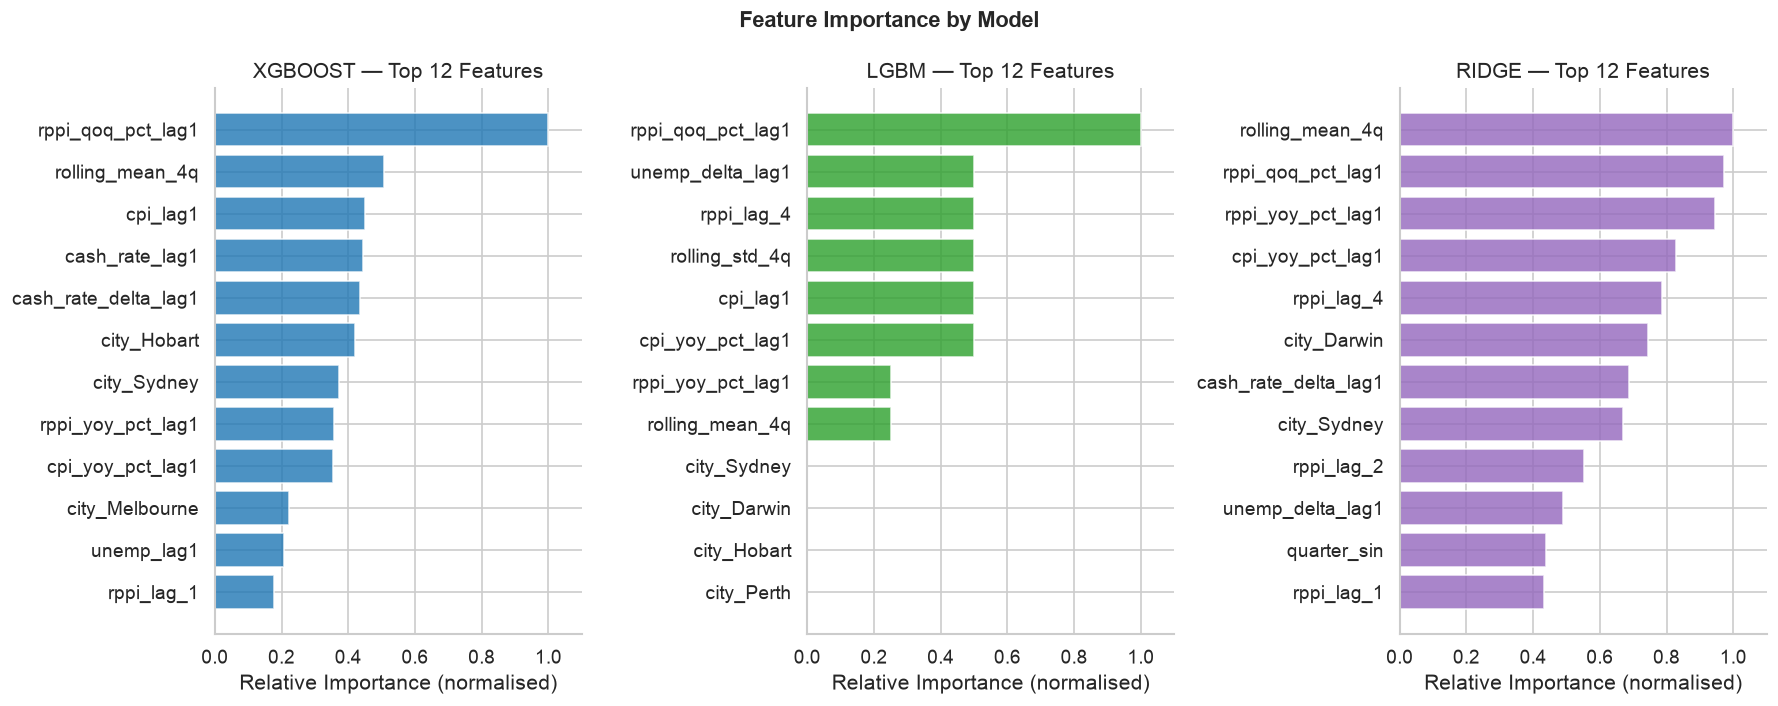

In [8]:
TOP_N = 12
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, (name, model) in zip(axes, models.items()):
    imp = model.get_feature_importance().head(TOP_N)
    # Normalise to 0-1 for comparability across models
    imp_norm = imp / imp.max()
    colors = [MODEL_COLORS[name]] * len(imp_norm)
    ax.barh(imp_norm.index[::-1], imp_norm.values[::-1], color=colors, alpha=0.8)
    ax.set_xlabel("Relative Importance (normalised)")
    ax.set_title(f"{name.upper()} — Top {TOP_N} Features")
    ax.set_xlim(0, 1.1)

plt.suptitle("Feature Importance by Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Residuals by City

Are errors uniformly distributed across cities, or are some cities systematically harder to predict? Thin markets (Darwin, Hobart) typically have higher volatility and thus larger residuals.

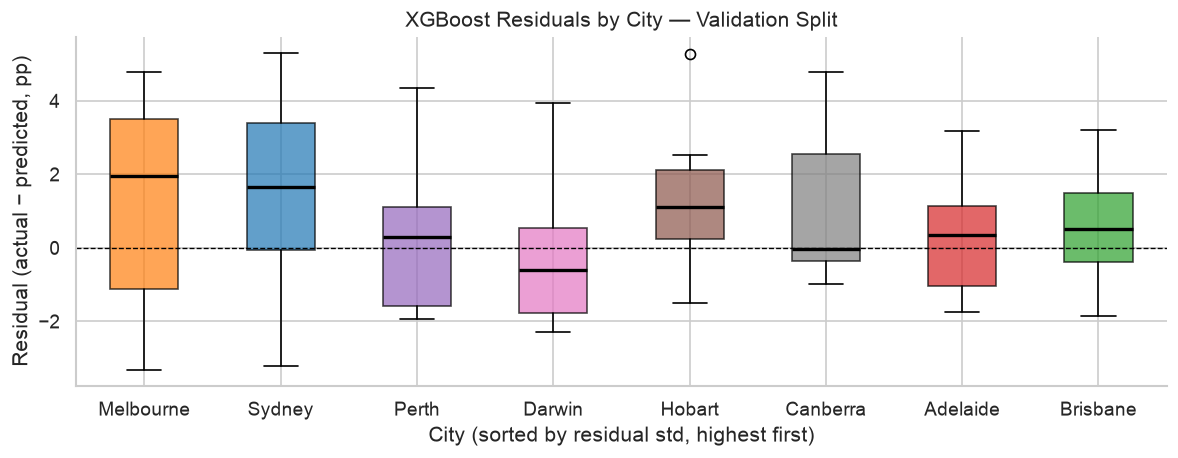

In [9]:
# Use best model (XGBoost) on val split
xgb = models["xgboost"]
val_rows = feat_df[
    (feat_df["period"] > pd.Period(SPLIT.train_end, freq="Q-DEC")) &
    (feat_df["period"] <= pd.Period(SPLIT.val_end,  freq="Q-DEC"))
].copy()
val_rows["pred"] = xgb.predict(X_val)
val_rows["residual"] = val_rows["target"] - val_rows["pred"]

fig, ax = plt.subplots(figsize=(10, 4))
city_order = val_rows.groupby("city")["residual"].std().sort_values(ascending=False).index
city_data = [val_rows[val_rows["city"] == c]["residual"].values for c in city_order]

bp = ax.boxplot(city_data, tick_labels=city_order, patch_artist=True, notch=False,
                medianprops={"color": "black", "linewidth": 2})
for patch, city in zip(bp["boxes"], city_order):
    patch.set_facecolor(CITY_COLORS[city])
    patch.set_alpha(0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("City (sorted by residual std, highest first)")
ax.set_ylabel("Residual (actual − predicted, pp)")
ax.set_title("XGBoost Residuals by City — Validation Split")
plt.tight_layout()
plt.show()

## 7. Residuals Over Time

Plotting residuals chronologically reveals whether errors are random or have time structure. A well-behaved model should have residuals that look like white noise — no visible trends, no clustering by period.

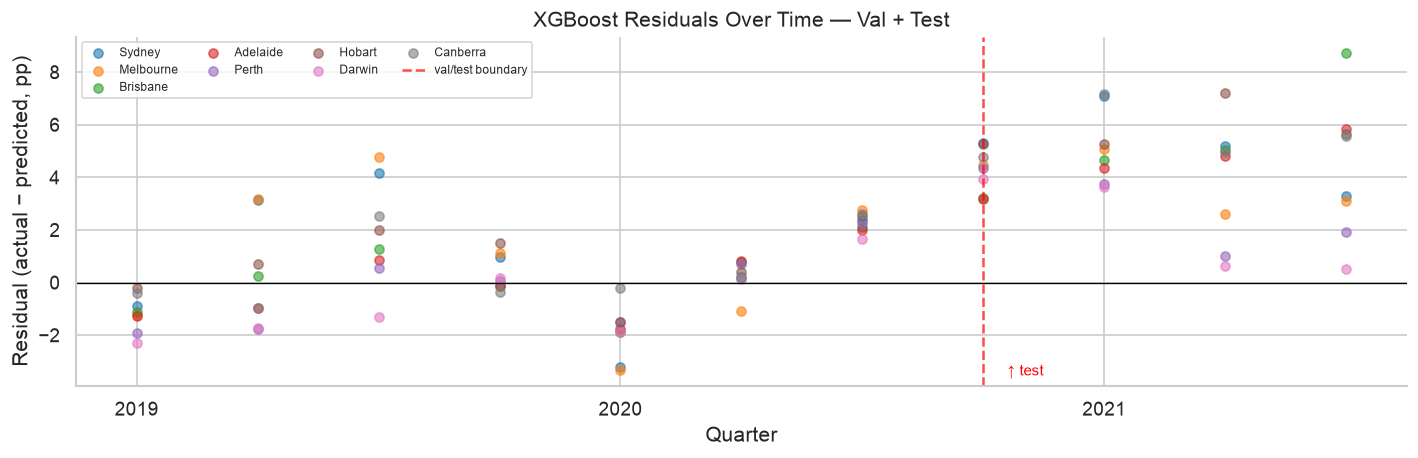

In [10]:
# Val + test residuals over time
all_oos = feat_df[feat_df["period"] > pd.Period(SPLIT.train_end, freq="Q-DEC")].copy()
X_oos = all_oos[pipeline.feature_cols]
all_oos["pred_xgb"] = xgb.predict(X_oos)
all_oos["residual"] = all_oos["target"] - all_oos["pred_xgb"]

fig, ax = plt.subplots(figsize=(12, 4))
for city in CITIES:
    df_city = all_oos[all_oos["city"] == city].sort_values("period")
    x = [str(p) for p in df_city["period"]]
    ax.scatter(x, df_city["residual"], color=CITY_COLORS[city], alpha=0.6, s=30, label=city)

all_x = [str(p) for p in sorted(all_oos["period"].unique())]
ax.axhline(0, color="black", linewidth=0.8)
val_end_x = str(pd.Period(SPLIT.val_end, freq="Q-DEC"))
if val_end_x in all_x:
    ax.axvline(all_x.index(val_end_x), color="red", linestyle="--",
               alpha=0.7, linewidth=1.5, label="val/test boundary")
    ax.text(all_x.index(val_end_x) + 0.2, ax.get_ylim()[0] * 0.9,
            "↑ test", color="red", fontsize=9)

tick_pos = [i for i, q in enumerate(all_x) if q.endswith("Q1")]
tick_lbl = [q[:4] for q in all_x if q.endswith("Q1")]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl)
ax.set_xlabel("Quarter")
ax.set_ylabel("Residual (actual − predicted, pp)")
ax.set_title("XGBoost Residuals Over Time — Val + Test")
ax.legend(fontsize=7, ncol=4, loc="upper left")
plt.tight_layout()
plt.show()

## 8. Directional Accuracy Deep-Dive

For many practical applications — buy/sell signals, risk flags — the question isn't *how much* prices will change but *whether they'll go up or down*. Here we evaluate directional accuracy more carefully.

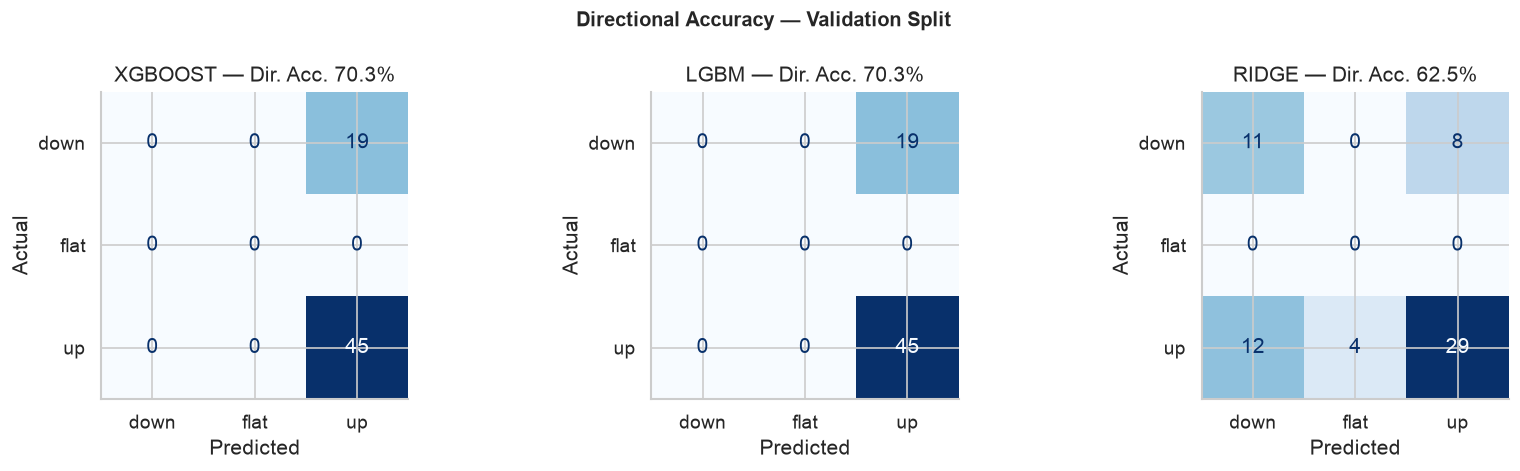

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def direction(arr):
    """Map values to 'up' / 'down' / 'flat' (within ±0.1pp)."""
    return np.where(arr > 0.1, "up", np.where(arr < -0.1, "down", "flat"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

y_val_dir = direction(y_val.values)
labels = ["down", "flat", "up"]

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_val)
    preds_dir = direction(preds)
    cm = confusion_matrix(y_val_dir, preds_dir, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    acc = np.mean(y_val_dir == preds_dir)
    ax.set_title(f"{name.upper()} — Dir. Acc. {acc:.1%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Directional Accuracy — Validation Split", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

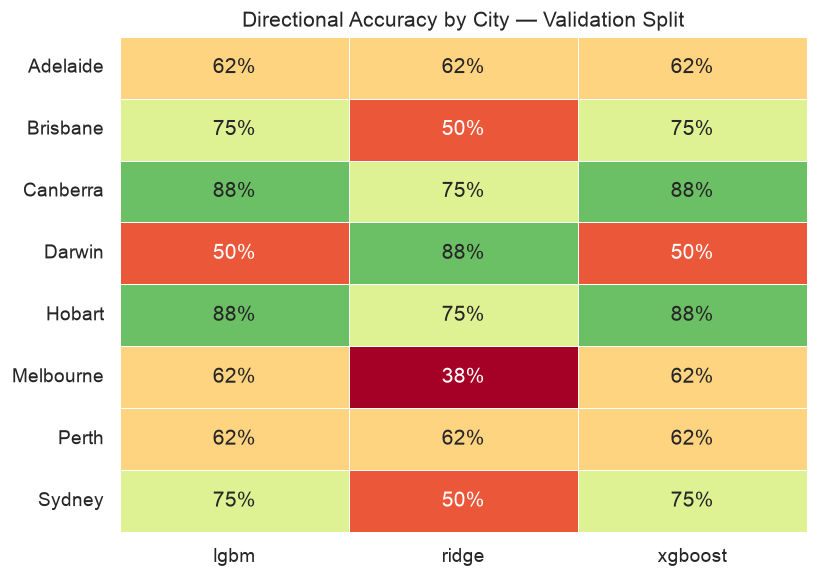

In [12]:
# Directional accuracy per city on val
val_rows2 = feat_df[
    (feat_df["period"] > pd.Period(SPLIT.train_end, freq="Q-DEC")) &
    (feat_df["period"] <= pd.Period(SPLIT.val_end,  freq="Q-DEC"))
].copy()

dir_rows = []
for name, model in models.items():
    preds = model.predict(X_val)
    for city in CITIES:
        mask = val_rows2["city"] == city
        y_c = val_rows2.loc[mask, "target"].values
        p_c = preds[mask.values]
        if len(y_c) == 0:
            continue
        acc = np.mean(np.sign(y_c) == np.sign(p_c))
        dir_rows.append({"model": name, "city": city, "dir_acc": acc})

dir_df = pd.DataFrame(dir_rows).pivot(index="city", columns="model", values="dir_acc")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(dir_df, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0.4, vmax=1.0,
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title("Directional Accuracy by City — Validation Split")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 9. Bottom Line — What Is This Model Actually Useful For?

### What it does well
- **Directional signals**: ~70% accuracy on val set in predicting whether prices will rise or fall next quarter. This is meaningfully better than the ~55% you'd get from a naive "always predict up" strategy in this period.
- **Identifying the macro channel**: Cash rate and momentum features dominate importance across all three models — consistent with economic intuition and academic literature on housing markets.
- **City differentiation**: The model correctly learns that Sydney/Melbourne behave differently from Darwin, even with limited data.

### What it does not do well
- **Point forecasts**: MAE of ~1.7pp on val means the error band is large relative to typical quarterly moves of 0.5–2pp. Don't use for precise magnitude prediction.
- **Regime changes**: The 2021 crash in test R² is not a bug — it's a fundamental limitation. Any model trained on historical data will fail when the macro environment shifts to levels outside the training range (0.1% cash rate in 2020 was unprecedented in the modern era).
- **Short training set**: Only ~32 quarters per city in training. Tree models with 50 Optuna trials are at risk of overfitting to the specific 2011–2018 pattern.

### What would improve it
1. **More recent data**: The ABS discontinued RPPI 6416.0 after Dec 2021; sourcing the replacement series would add 3+ years of data including the 2022–2023 rate-hike cycle.
2. **Macro regime features**: Include an indicator for rate-hike vs rate-cut cycles, or use credit growth data (RBA D1/D2 series).
3. **Supply-side data**: New dwelling approvals, vacancy rates — demand-side models are inherently limited.
4. **Longer history**: RBA F1 data only goes back to 2011; older data would help capture more rate cycles.